In [1]:
## 지도 학습
# 분류: 예측 값이 이산형 클래스깞
# 회귀: 연속형 숫자값

In [3]:
## 선형 회귀
# 실제값과 예측값 차이(오류의 제곱값)을 최소화하는 직선형 회귀선을 최적화하는 방식

In [7]:
## 5.2 단순 선형회귀를 통한 회귀 이해
# 전체 데이터의 오류값의 제곱합이 최소가 되는 모델
# RSS(비용함수) : w변수(회귀 계수)로 구성됨 = 손실함수(loss function)
# 머신러닝 회귀알고리즘은 이 비용함수가 반환하는 값(즉, 오류값)을 지속해서 감소시키고 최종적으로 더이상 감소하지 않는 최소 오류값을 구하는 것

In [1]:
## 5.3 비용최소화하기 - 경사하강법(gradient descent)
# 반복적인 계산을 통해 w 파라미터 값을 업데이트하면서 오류값이 최소가 되는 w파라미터를 구하는 방식

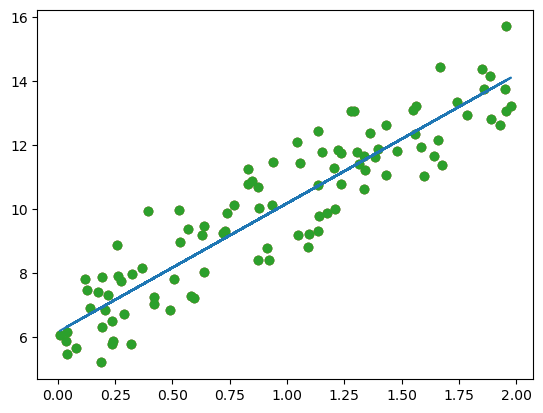

In [31]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4x+6을 근사(w1=4, w0=6) 임의의 값은 노이즈를 위해 만듦
X = 2 * np.random.rand(100,1)
y = 6 + 4*X + np.random.randn(100,1)

# X,y 데이터세트 산점도로 시각화
plt.scatter(X,y)
plt.show()

In [33]:
def get_cost(y,y_pred):
    N=len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

In [35]:
# w1 과 w0를 업데이트할 w1update, w0update를 반환
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N = len(y)
    # 먼저 w1update, w0update를 각각 w1,w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1update = np.zeros_like(w1)
    w0update = np.zeros_like(w0)
    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X,w1.T) + w0
    diff = y-y_pred
    # w0update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N,1))
    # W1과 W0을 업데이트할 update 계산
    w1update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))
    return w1update,w0update

In [53]:
# 입력인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함
def gradient_descent_steps(X,y,iters=10000):
    # w0와 w1을 모두 0으로 초기화
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1,w0 업데이트 수행
    for ind in range(iters):
        w1update ,w0update = get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1 = w1-w1update
        w0 = w0-w0update 
    return w1,w0

In [55]:
# 예측값과 실제값의 rss 차이를 계산하는 get_cost()함수
def get_cost(y,y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X,y,iters=1000)
print(f'w1:{w1[0,0]}, w0:{w0[0,0]}')
y_pred = w1[0,0] * X + w0
print(f'gradient descent total cost: {get_cost(y,y_pred)}')

w1:4.021813642697164, w0:6.162031224717461
gradient descent total cost: 0.9934784315632568


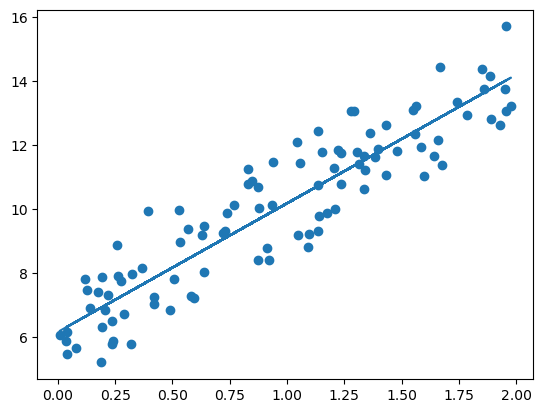

In [57]:
plt.scatter(X,y)
plt.plot(X, y_pred)
plt.show()

In [67]:
# 확률적 경사하강법 - 대용량 데이터에서 입력데이터의 일부만 활용해 w가 업데이트되는 값을 계싼
def stochastic_gradient_descent_steps(X,y,batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X,y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X,sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batchsize만큼 추출된 데이터 기반으로 w1update,w0update 계산후 업데이트
        w1update ,w0update = get_weight_updates(w1,w0,sample_X,sample_y,learning_rate=0.01)
        w1 = w1-w1update
        w0 = w0-w0update
    return w1,w0

In [69]:
w1,w0 = stochastic_gradient_descent_steps(X,y,iters=1000)
print(f'w1:{round(w1[0,0],3)},w0:{round(w0[0,0],3)}')
y_pred = w1[0,0]*X +w0
print(f'stochastic gradient descent total cost:{get_cost(y,y_pred)}')

w1:4.028,w0:6.156
stochastic gradient descent total cost:0.9937111256675345


In [3]:
# linear regression 클래스
# class sklearn.linear_model.LinearRegression(fit_intercept=True,normalize=False,copy_X=True,n_jobs=1)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
# load_boston 대신 fetch_california_housing로 대체
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# california 데이터세트 로드
california = fetch_california_housing()

# california 데이터세트 dataframe 변환
californiaDF = pd.DataFrame(california.data, columns = california.feature_names)

# target 배열은 주택 가격. 이를 PRICE 칼럼으로 dataframe에 추가함
californiaDF['PRICE'] = california.target 
print('데이터세트 크기:' , californiaDF.shape)
californiaDF.head()

데이터세트 크기: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


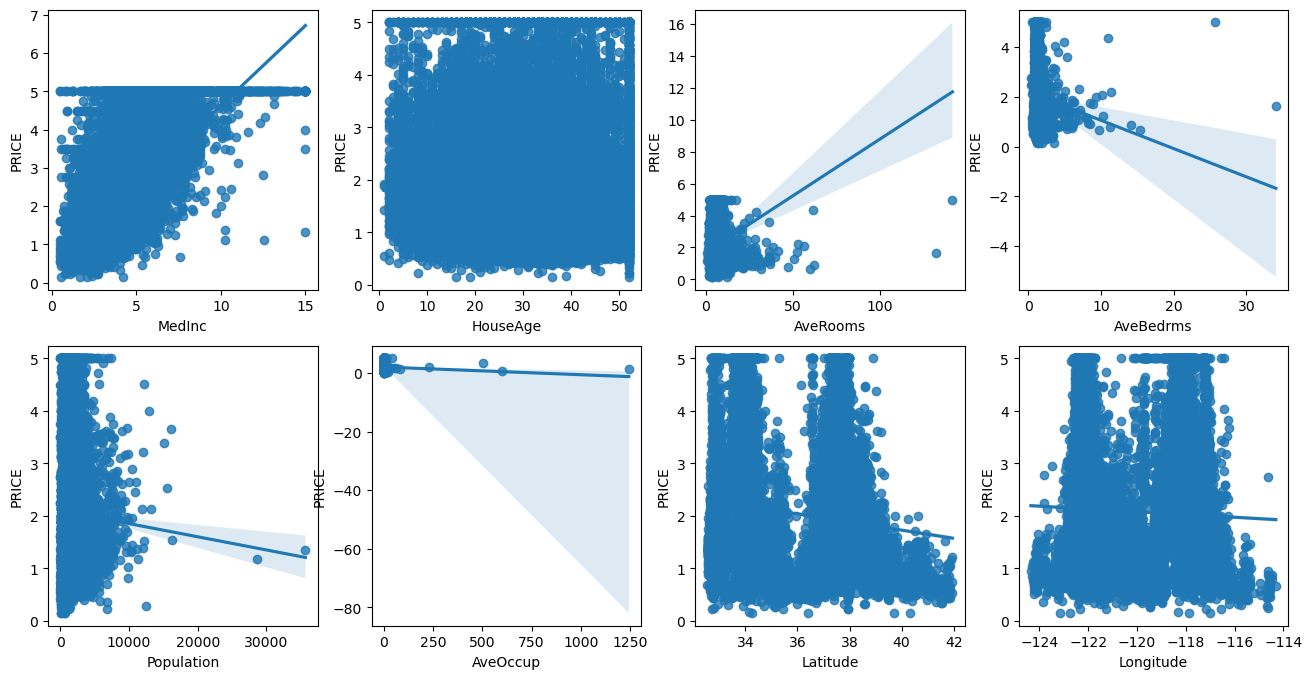

In [16]:
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['MedInc', 'HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='PRICE', data=californiaDF, ax=axs[row][col])

plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = californiaDF['PRICE']
X_data = californiaDF.drop(['PRICE'],axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3,random_state=156)

# 선형 회귀 OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train,y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print(mse, rmse)
print('variance score', r2_score(y_test,y_preds))

0.5427375001577448 0.7367072011034945
variance score 0.5952253366499458


In [23]:
# 절편(w0)과 회귀 계수(기울기, w1~w8) 확인하기
print('절편 값 (w0):', lr.intercept_)
print('회귀 계수값 (기울기):', np.round(lr.coef_, 1))

절편 값 (w0): -37.23905305294165
회귀 계수값 (기울기): [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [25]:
from sklearn.model_selection import cross_val_score
y_target = californiaDF['PRICE']
X_data = californiaDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score()로 5폴드 세트로 mse 값을 구한뒤 이를 기반으로 다시 rmse 구함
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring='neg_mean_squared_error')로 반환된 값은 모두 음수
print('5fold 개별 negative mse score', np.round(neg_mse_scores,2))
print('5fold 개별 rmse score', np.round(rmse_scores,2))
print('5fold 평균 rmse', avg_rmse)

5fold 개별 negative mse score [-0.48 -0.62 -0.65 -0.54 -0.49]
5fold 개별 rmse score [0.7  0.79 0.8  0.74 0.7 ]
5fold 평균 rmse 0.7459068363518117


In [27]:
# 다항 회귀가 비선형회귀인건 아님
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환된 단항식 생성, [[0,1],[2,3]] 의 2x2 행렬생성
X = np.arange(4).reshape(2,2)
print('일차단항식 계수 피처',X)

# degree = 2 인 2차 다항식으로 변환하기 위해 polynomialfeatures를 이용해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 피처', poly_ftr)

일차단항식 계수 피처 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [29]:
def polynomial_func(X):
    y = 1+2*X[:,0]+3*X[:,0]**2+4*X[:,1]**3
    return y

X = np.arange(4).reshape(2,2)
y = polynomial_func(X)
y

array([  5, 125])

In [31]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수', poly_ftr)

# linear regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('polynomial 회귀계수', np.round(model.coef_,2))
print('polynomial 회귀 shape', model.coef_.shape)

3차 다항식 계수 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
polynomial 회귀계수 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
polynomial 회귀 shape (10,)


In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1+2*X[:,0]+3*X[:,0]**2+4*X[:,1]**3
    return y

# pipeline 객체로 streamline 하게 polynomial feature 변환과 linear regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear',LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X,y)

print('polynomial 회귀계수', np.round(model.named_steps['linear'].coef_,2))

polynomial 회귀계수 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


degree1의 회귀계수는 [-1.61]입니다.
degree1의 mse는 0.40772896250986834입니다.
degree4의 회귀계수는 [  0.47 -17.79  23.59  -7.26]입니다.
degree4의 mse는 0.04320874987231747입니다.
degree15의 회귀계수는 [-2.98295000e+03  1.03899930e+05 -1.87417069e+06  2.03717225e+07
 -1.44873988e+08  7.09318780e+08 -2.47066977e+09  6.24564048e+09
 -1.15677067e+10  1.56895696e+10 -1.54006776e+10  1.06457788e+10
 -4.91379977e+09  1.35920330e+09 -1.70381654e+08]입니다.
degree15의 mse는 182815433.47648773입니다.


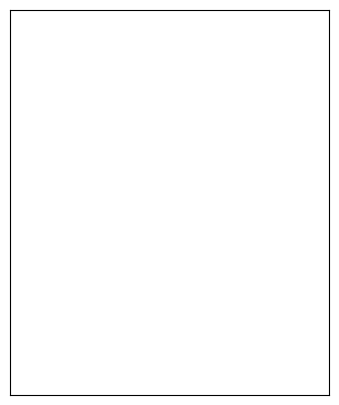

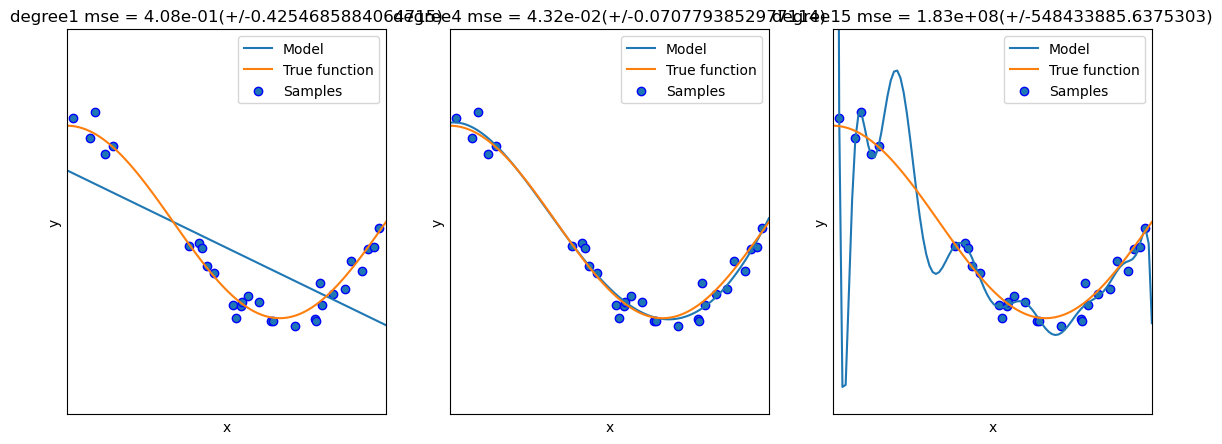

In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 x값에 대해 코사인 변환 값을 반환
def true_fun(X):
    return np.cos(1.5*np.pi *X)

# X 는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터
np.random.seed(0)
n_samples =30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동값을 더한 값
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14,5))
degrees = [1,4,15]

# 다항 회귀의 차수를 1,4,15로 각각 변화시키면서 비교
for i in range(len(degrees)):
    ax = plt.subplot(1,len(degrees),i+1)
    plt.setp(ax, xticks=(), yticks=())
    # 개별 degree 별로 polynomial 변환
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([('polynomial_features', polynomial_features),('linear_regression',linear_regression)])
    pipeline.fit(X.reshape(-1,1),y)
    # 교차검증으로 다항회귀 평가
    scores = cross_val_score(pipeline, X.reshape(-1,1), y, scoring='neg_mean_squared_error', cv=10)
    # pipeline을 구성하는 세부객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print(f'degree{degrees[i]}의 회귀계수는 {np.round(coefficients,2)}입니다.')
    print(f'degree{degrees[i]}의 mse는 {-1*np.mean(scores)}입니다.')
    # 0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행한다
    # 테스트 데이터 세트에 회귀예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교한다
    X_test = np.linspace(0,1,100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:,np.newaxis]), label='Model')
    # 실제값 곡선
    plt.plot(X_test, true_fun(X_test),'-', label='True function')
    plt.scatter(X, y,edgecolor='b',label='Samples')
    plt.xlabel('x');plt.ylabel('y');plt.xlim((0,1)); plt.ylim((-2,2)); plt.legend(loc='best')
    plt.title(f'degree{degrees[i]} mse = {-scores.mean():.2e}(+/-{scores.std()})')

plt.show()

In [ ]:
# degree1의 예측곡선은 단순한 직선으로서 단순선형회귀와 같다. 실제데이터 세트인 코사인데이터세트를 직선으로 예측하기엔 단순
# 예측 곡선이 학습데이터의 패턴을 잘 파악하지 못하고 과소적합 모델이됨

# degree4 가 비교적 잘 반영

# degree15 는 mse 값이 182815433.47648773가 될 정도로 오류값 발생 데이터세트의 변동잡음 값까지 지나치게 반영하여 과적합